# LeetCode #7: Reverse Integer

https://leetcode.com/problems/reverse-integer/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (String Conversion)** | $O(\log n)$ | $O(\log n)$ |
| **Math Digit Extraction** ★ | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (String Conversion)
Convert the integer to a string, reverse the character array, and parse it back. Allocates two string objects of size $O(\log n)$ and typically requires a try-catch block to handle parse overflow — computationally expensive.

### Optimal: Math Digit Extraction ★
Extract digits using the modulo operator (`% 10`) and build the reversed number by multiplying the accumulator by 10 and adding the digit. The critical step is checking for 32-bit overflow **before** the multiply, not after.

**Why this is better than String Conversion:** Identical $O(\log n)$ time, but $O(1)$ space — no string allocation. Overflow is caught pre-emptively by comparing to `INT_MAX / 10` before multiplying, avoiding undefined behavior.

**Constraints:**
* `-2^31 <= x <= 2^31 - 1`
* Return `0` if the reversed integer overflows the 32-bit signed integer range

## Solutions

### C#

In [ ]:
public class Solution {
    public int Reverse(int x) {
        int rev = 0;
        while (x != 0) {
            int pop = x % 10;
            x /= 10;
            // Catch overflow before it happens — INT_MAX ends in 7, INT_MIN ends in -8
            if (rev > int.MaxValue / 10 || (rev == int.MaxValue / 10 && pop > 7)) return 0;
            if (rev < int.MinValue / 10 || (rev == int.MinValue / 10 && pop < -8)) return 0;
            rev = rev * 10 + pop;
        }
        return rev;
    }
}

### Python

In [ ]:
class Solution:
    def reverse(self, x: int) -> int:
        INT_MAX = 2**31 - 1
        sign = -1 if x < 0 else 1
        x = abs(x)
        rev = 0
        while x != 0:
            pop = x % 10
            x //= 10
            # Catch overflow before it happens — INT_MAX ends in 7
            if rev > INT_MAX // 10 or (rev == INT_MAX // 10 and pop > 7):
                return 0
            rev = rev * 10 + pop
        return rev * sign

### Go

In [ ]:
import "math"

func reverse(x int) int {
    rev := 0
    for x != 0 {
        pop := x % 10
        x /= 10
        // Catch overflow before it happens — INT_MAX ends in 7, INT_MIN ends in -8
        if rev > math.MaxInt32/10 || (rev == math.MaxInt32/10 && pop > 7) {
            return 0
        }
        if rev < math.MinInt32/10 || (rev == math.MinInt32/10 && pop < -8) {
            return 0
        }
        rev = rev*10 + pop
    }
    return rev
}

### Rust

In [ ]:
impl Solution {
    pub fn reverse(x: i32) -> i32 {
        let mut rev: i32 = 0;
        let mut x = x;
        while x != 0 {
            let pop = x % 10;
            x /= 10;
            // Catch overflow before it happens — i32::MAX ends in 7, i32::MIN ends in -8
            if rev > i32::MAX / 10 || (rev == i32::MAX / 10 && pop > 7) {
                return 0;
            }
            if rev < i32::MIN / 10 || (rev == i32::MIN / 10 && pop < -8) {
                return 0;
            }
            rev = rev * 10 + pop;
        }
        rev
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `x = 123`  
Three iterations: pop 3 (rev=3), pop 2 (rev=32), pop 1 (rev=321). Each overflow check passes easily since rev stays far below $2^{31}/10$.  
**Result:** `321`

### 2. Slightly Complex (Negative Number)
**Input:** `x = -123`  
C#, Go, and Rust modulo inherits the sign of the dividend: `-123 % 10 = -3`. Negative pops build a negative rev correctly without special handling. Python uses `abs(x)` then multiplies by sign at the end.  
**Result:** `-321`

### 3. Edge Case: Time Factor (Trailing Zeros)
**Input:** `x = 1000000000`  
Ten iterations run for this 10-digit number ($O(\log_{10} n)$ steps). The first nine pops are 0 (rev stays 0), then the final pop is 1. Leading zeros in the reversed number vanish naturally — the integer representation never stores them.  
**Result:** `1`

### 4. Edge Case: Space Factor (Palindrome Near INT_MAX)
**Input:** `x = 1000000001`  
Reversed = 1000000001 (a palindrome). The math approach only ever holds two integers (`rev` and `pop`) — $O(1)$ space. The string approach would allocate two 10-character strings on the heap for the conversion and reversal.  
**Result:** `1000000001`

### 5. Almost-Impossible but Plausible: Valid Input Whose Reverse Overflows
**Input:** `x = 1534236469`  
A valid 32-bit integer, but its reverse (9,643,234,351) far exceeds INT_MAX (2,147,483,647). The overflow check fires on iteration 10 when rev = 964,632,435 — already greater than INT_MAX/10 = 214,748,364. The multiply is never attempted.  
**Result:** `0`

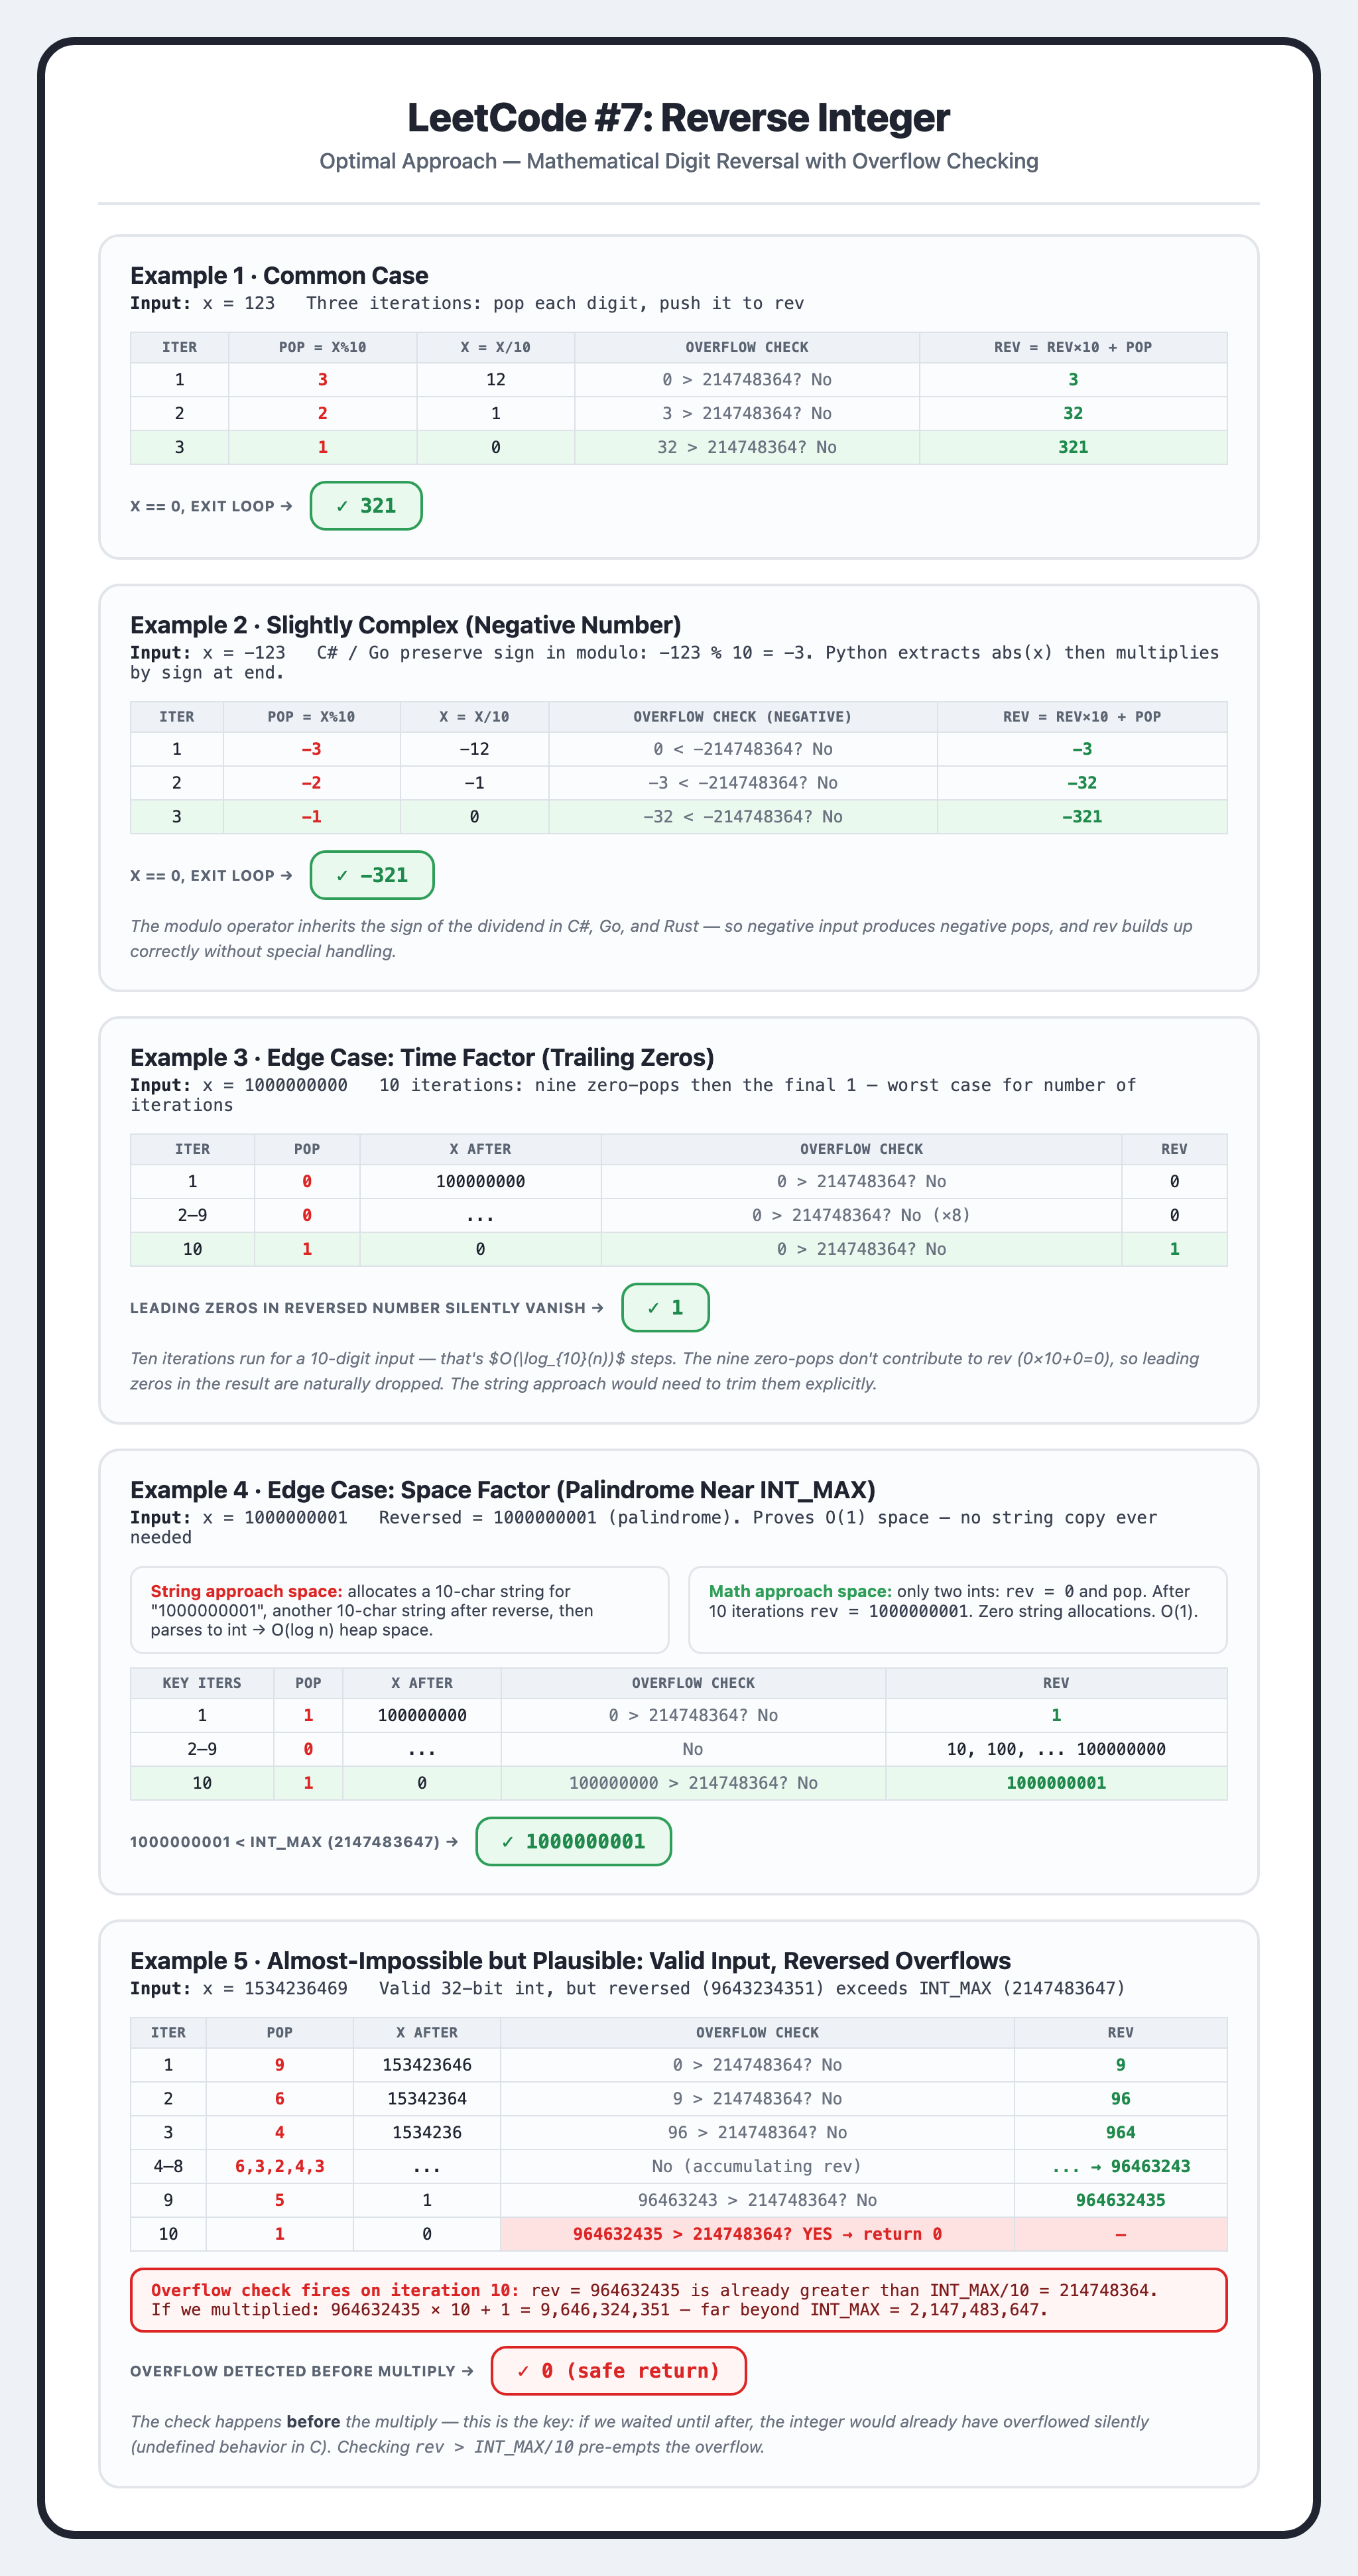